<div style="font-family: system-ui, -apple-system, sans-serif; text-align: center; padding: 48px 24px 24px;">
    <div style="display: inline-block; background: #be0f05; color: white;
                padding: 12px 20px; border-radius: 12px; margin-bottom: 20px;">
        <span style="font-size: 34px; font-weight: 800; letter-spacing: -0.5px;">TIP4PATLIBS &ndash; Advanced &mdash; the technology network</span>
    </div>
    <div style="font-size: 16px; color: #475569; margin-bottom: 8px; line-height: 1.6;">
        Which technology fields appear <em>together</em> on the same patent families &mdash; the IPC co-occurrence network that reveals how the field's technologies combine.
    </div>
    <div style="font-size: 13px; color: #94a3b8; margin-bottom: 32px;">
        EPO Academy Training Material &nbsp;&middot;&nbsp; landscape analyses after <span style="color: #be0f05; font-weight: 600;">Riccardo Priore</span>, Centro PATLIB, AREA Science Park
    </div>
    <div style="background: #f8fafc; border-radius: 12px; padding: 24px 28px; max-width: 680px;
                margin: 0 auto; border: 1px solid #e2e8f0; text-align: left;">
        <div style="font-size: 14px; color: #334155; line-height: 1.9;">
            <strong>What this notebook does</strong>
            <br/>Step&nbsp;1 &nbsp;&middot;&nbsp; Load the shared corpus<br/>Step&nbsp;2 &nbsp;&middot;&nbsp; The technology-field dictionary<br/>Step&nbsp;3 &nbsp;&middot;&nbsp; Significant IPC codes (&ge;50 families)<br/>Step&nbsp;4 &nbsp;&middot;&nbsp; Which fields co-occur (self-join)<br/>Step&nbsp;5 &nbsp;&middot;&nbsp; Build and draw the network
        </div>
    </div>
    <div style="background: #fdf2f2; border-radius: 10px; padding: 16px 24px; max-width: 680px;
                margin: 28px auto 0; border: 1px solid #fecaca;">
        <div style="font-size: 14px; color: #404955; font-weight: 600;">&#9654; &nbsp;Part 3 of 4 &mdash; run the four notebooks of this module in order.</div>
        <div style="font-size: 12px; color: #64748b; margin-top: 6px; line-height: 1.6;">
            Re-running needs <strong>EPO&nbsp;TIP</strong> (it queries PATSTAT&nbsp;PROD via <code>epo.tipdata</code>).
            Each notebook writes what the next one reads; notebook&nbsp;4 assembles the report.
        </div>
    </div>
    <div style="margin-top: 20px; font-size: 12px; color: #cbd5e1;">
        Part of EPO TIP Working Group Sessions, 2026. &nbsp;Data: EPO PATSTAT Global.
    </div>
</div>

## Step 1 — Load the shared corpus

As before, we read `dataset.xlsx` and take the family-id list. This notebook works at the **8-character IPC** level (subclass + main group, e.g. `A61K  31`) throughout.

In [1]:
import pandas as pd
import networkx as nx
import plotly.graph_objects as go
from sqlalchemy import and_, func, orm as sa_orm

from epo.tipdata.patstat import PatstatClient
from epo.tipdata.patstat.database.models import TLS201_APPLN, TLS209_APPLN_IPC
import report_kit

patstat = PatstatClient(env='PROD')
db = patstat.orm()

OUT = "3_advanced_analyses_output"
import os; os.makedirs(OUT, exist_ok=True)

dataset = pd.read_excel("1_dataset_and_search_strategy_output/dataset.xlsx")
all_families = [int(f) for f in dataset['docdb_family_id'].dropna().unique()]
print(f"{len(all_families):,} families loaded.")

4,172 families loaded.


## Step 2 — The technology-field dictionary

IPC codes are opaque, so we map each 8-character code to a **readable technology field**. The resolver tries the 8-, then 4-, then 3-character prefix. A second, shorter naming is used purely to label the network nodes compactly. This dictionary is the one piece of domain knowledge that turns codes into a story.

In [2]:
ipc_to_tech_field = {
    'A61K  31': 'Antibiotic Drugs - Organic Compounds',
    'A61K  38': 'Antibiotic Drugs - Peptides',
    'A61K  39': 'Antibiotic Drugs - Antigens/Antibodies',
    'A61K  45': 'Antibiotic Drug Combinations',
    'A61K  47': 'Antibiotic Drug Formulations',
    'A61K   9': 'Antibiotic Drug Delivery',
    'A61P  31': 'Antiinfective Therapeutics',
    'A61P  43': 'Drug Screening Methods',
    'C12Q   1': 'Microorganism Detection & Testing',
    'C12Q   3': 'Microbial Activity Testing',
    'G01N  33': 'Diagnostic Analysis Methods',
    'G01N  27': 'Electrochemical Analysis',
    'G01N  21': 'Optical Analysis',
    'G01N  15': 'Particle Analysis',
    'C12N   1': 'Bacteria & Microorganisms',
    'C12N   5': 'Cell Culture',
    'C12N  15': 'Genetic Engineering',
    'C12N   9': 'Enzymes',
    'C12P   1': 'Antibiotic Fermentation',
    'C12P  17': 'Peptide Production',
    'C12P  21': 'Protein Production',
    'C07D': 'Antibiotic Chemistry - Heterocyclic',
    'C07K': 'Antibiotic Chemistry - Peptides',
    'C07K   7': 'Short Peptide Antibiotics',
    'C07K  14': 'Therapeutic Peptides',
    'C07K  16': 'Antibody Therapeutics',
    'C07C': 'Antibiotic Chemistry - Organic',
    'C07H': 'Antibiotic Chemistry - Carbohydrates',
    'G01N': 'Analytical Testing',
    'A61B': 'Medical Diagnostic Devices',
    'A61L': 'Antimicrobial Materials & Sterilization',
    'A61L  31': 'Antimicrobial Coatings',
    'A61L   2': 'Sterilization Methods',
    'A61M': 'Medical Treatment Devices',
    'C01B': 'Inorganic Compounds',
    'A61': 'Medical & Pharmaceutical Technology',
    'B01': 'Chemical Processing',
    'B82': 'Nanotechnology',
    'C02': 'Water Treatment',
    'C07': 'Organic Chemistry',
    'C08': 'Polymer Chemistry',
    'C12': 'Biochemistry',
    'G01': 'Measuring & Testing',
    'G06': 'Computing & Data Processing',
}

def get_technology_field(ipc_code):
    for n in (8, 4, 3):
        key = ipc_code[:n]
        if key in ipc_to_tech_field:
            return ipc_to_tech_field[key]
    return f"Technology Field ({ipc_code[:3]})"

_simplify = {
    'Antibiotic Drugs - Organic Compounds': 'Antibiotic Drugs (Organic)',
    'Antibiotic Drugs - Peptides': 'Antibiotic Drugs (Peptides)',
    'Antibiotic Drugs - Antigens/Antibodies': 'Antibiotic Drugs (Antibodies)',
    'Antibiotic Chemistry - Heterocyclic': 'Chemistry (Heterocyclic)',
    'Antibiotic Chemistry - Peptides': 'Chemistry (Peptides)',
    'Microorganism Detection & Testing': 'Microorganism Testing',
    'Antimicrobial Materials & Sterilization': 'Antimicrobial Materials',
}

def get_simplified_tech_name(tech_field, ipc_code=None):
    return _simplify.get(tech_field, tech_field)

print(f"{len(ipc_to_tech_field)} IPC codes mapped to technology fields.")

44 IPC codes mapped to technology fields.


## Step 3 — Which IPC codes are significant (≥ 50 families)

We retrieve every family's IPC codes (filings from 2000 on), truncate to 8 characters, and keep only codes that appear in at least **50 distinct families**. These significant codes become the candidate nodes of the network.

In [3]:
FAMILY_THRESHOLD = 50

ipc_rows = (db.query(
        TLS201_APPLN.docdb_family_id.label('family'),
        TLS209_APPLN_IPC.ipc_class_symbol.label('IPC'))
    .join(TLS209_APPLN_IPC, TLS201_APPLN.appln_id == TLS209_APPLN_IPC.appln_id)
    .filter(TLS201_APPLN.docdb_family_id.in_(all_families))
    .filter(TLS201_APPLN.earliest_filing_year >= 2000).all())
df_ipc = pd.DataFrame(ipc_rows, columns=['family', 'IPC'])
df_ipc['IPC_8'] = df_ipc['IPC'].astype(str).str[:8]

fam_per_ipc = df_ipc.groupby('IPC_8')['family'].nunique()
significant = fam_per_ipc[fam_per_ipc >= FAMILY_THRESHOLD]
significant_ipc_list = significant.index.tolist()
sig_tbl = (pd.DataFrame({'IPC_Code': significant.index, 'Family_Count': significant.values})
           .assign(Technology_Field=lambda d: d['IPC_Code'].map(get_technology_field))
           .sort_values('Family_Count', ascending=False).reset_index(drop=True))
print(f"{len(significant_ipc_list)} significant IPC codes (>= {FAMILY_THRESHOLD} families).")

61 significant IPC codes (>= 50 families).


## Step 4 — Which fields co-occur (an IPC self-join)

Co-occurrence means two different IPC codes on the **same application**. A self-join of the IPC table against itself gives every unordered pair (the `>` comparison avoids duplicates and self-pairs; the 8-character comparison drops trivially-close pairs). We keep only pairs where *both* codes are significant, then count how often each pair occurs.

In [4]:
IPC2 = sa_orm.aliased(TLS209_APPLN_IPC)
co_rows = (db.query(
        TLS201_APPLN.docdb_family_id.label('family'),
        TLS209_APPLN_IPC.ipc_class_symbol.label('IPC_1'),
        IPC2.ipc_class_symbol.label('IPC_2'))
    .join(TLS209_APPLN_IPC, TLS201_APPLN.appln_id == TLS209_APPLN_IPC.appln_id)
    .join(IPC2, TLS201_APPLN.appln_id == IPC2.appln_id)
    .filter(TLS201_APPLN.docdb_family_id.in_(all_families))
    .filter(TLS201_APPLN.earliest_filing_year >= 2000)
    .filter(and_(
        TLS209_APPLN_IPC.ipc_class_symbol > IPC2.ipc_class_symbol,
        func.left(TLS209_APPLN_IPC.ipc_class_symbol, 8) != func.left(IPC2.ipc_class_symbol, 8),
    )).all())
df_co = pd.DataFrame(co_rows, columns=['family', 'IPC_1', 'IPC_2'])
df_co['IPC_1_8'] = df_co['IPC_1'].astype(str).str[:8]
df_co['IPC_2_8'] = df_co['IPC_2'].astype(str).str[:8]
df_co = df_co[df_co['IPC_1_8'].isin(significant_ipc_list)
              & df_co['IPC_2_8'].isin(significant_ipc_list)].drop_duplicates()

df_co['pair'] = df_co.apply(lambda r: tuple(sorted([r['IPC_1_8'], r['IPC_2_8']])), axis=1)
pair_counts = df_co.groupby('pair').size().reset_index(name='cooccurrence_count')
pair_counts[['IPC_A', 'IPC_B']] = pd.DataFrame(pair_counts['pair'].tolist(), index=pair_counts.index)
pair_counts['Tech_Field_A'] = pair_counts['IPC_A'].map(get_technology_field)
pair_counts['Tech_Field_B'] = pair_counts['IPC_B'].map(get_technology_field)
pair_counts = pair_counts.sort_values('cooccurrence_count', ascending=False).reset_index(drop=True)
edges_tbl = pair_counts[['IPC_A', 'Tech_Field_A', 'IPC_B', 'Tech_Field_B', 'cooccurrence_count']]
print(f"{len(pair_counts)} significant IPC pairs.")

1303 significant IPC pairs.


## Step 5 — Build and draw the network

Codes that share a (simplified) technology name are merged into one node; edges connect fields that co-occur at least **5** times. Node size and colour follow how many families carry the field; edge width follows how strongly two fields co-occur. A deterministic spring layout (`seed=42`) places the nodes. This is the notebook's chart — and it carries two data sheets (nodes and edges) into the workbook.

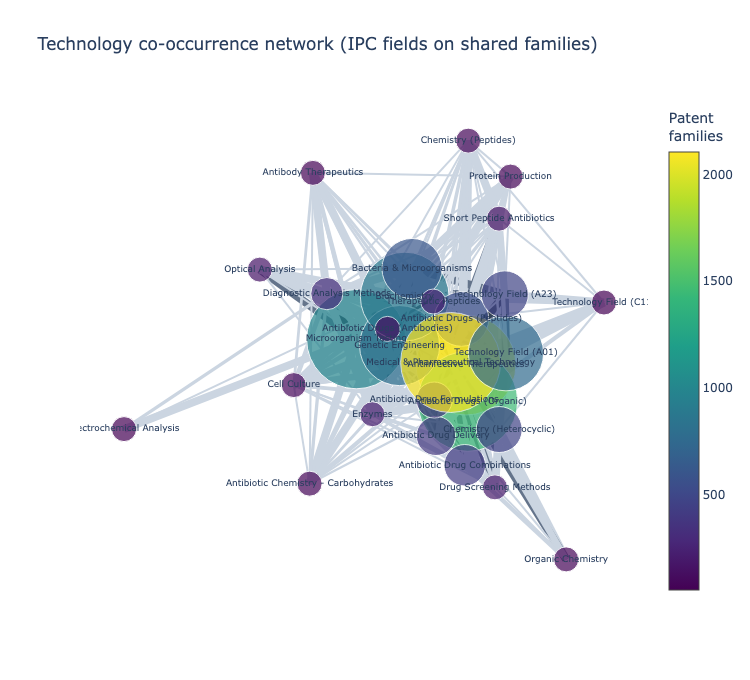

Network: 29 nodes, 298 edges.


In [5]:
EDGE_THRESHOLD = 5

# node families by simplified technology name
node_fams = {}
for _, r in sig_tbl.iterrows():
    name = get_simplified_tech_name(get_technology_field(r['IPC_Code']), r['IPC_Code'])
    node_fams[name] = node_fams.get(name, 0) + int(r['Family_Count'])

# edges aggregated by simplified-name pair
edge_w = {}
for _, r in pair_counts.iterrows():
    a = get_simplified_tech_name(r['Tech_Field_A'], r['IPC_A'])
    b = get_simplified_tech_name(r['Tech_Field_B'], r['IPC_B'])
    if a == b:
        continue
    key = tuple(sorted([a, b]))
    edge_w[key] = edge_w.get(key, 0) + int(r['cooccurrence_count'])
edge_w = {k: w for k, w in edge_w.items() if w >= EDGE_THRESHOLD}

G = nx.Graph()
for name, fam in node_fams.items():
    G.add_node(name, family_count=fam)
for (a, b), w in edge_w.items():
    if a in G and b in G:
        G.add_edge(a, b, weight=w)
G.remove_nodes_from([n for n in list(G.nodes) if G.degree(n) == 0])

pos = nx.spring_layout(G, k=3, iterations=50, seed=42)
avg_w = (sum(d['weight'] for *_, d in G.edges(data=True)) / max(1, G.number_of_edges()))

edge_traces = []
for a, b, d in G.edges(data=True):
    w = d['weight']
    colour = '#334155' if w > 2 * avg_w else ('#64748b' if w > avg_w else '#cbd5e1')
    edge_traces.append(go.Scatter(
        x=[pos[a][0], pos[b][0], None], y=[pos[a][1], pos[b][1], None],
        mode='lines', line=dict(width=max(2, min(8, w / 10)), color=colour),
        hoverinfo='none', showlegend=False))

nx_, ny, ntext, nsize, ncolour = [], [], [], [], []
for n, d in G.nodes(data=True):
    nx_.append(pos[n][0]); ny.append(pos[n][1]); ntext.append(n)
    nsize.append(max(25, min(100, d['family_count'] / 10)))
    ncolour.append(d['family_count'])
node_trace = go.Scatter(
    x=nx_, y=ny, mode='markers+text', text=ntext, textposition='middle center',
    textfont=dict(size=9), hovertext=[f"{t}: {c} families" for t, c in zip(ntext, ncolour)],
    hoverinfo='text',
    marker=dict(size=nsize, color=ncolour, colorscale='Viridis', showscale=True,
                colorbar=dict(title='Patent<br>families'), line=dict(color='white', width=1)))

fig = go.Figure(edge_traces + [node_trace])
fig.update_layout(
    title='Technology co-occurrence network (IPC fields on shared families)',
    showlegend=False, template='plotly_white', height=680,
    xaxis=dict(visible=False), yaxis=dict(visible=False))

nodes_tbl = (pd.DataFrame([{'Technology_Field': n, 'Patent_Families': d['family_count'],
                            'Connections': G.degree(n)} for n, d in G.nodes(data=True)])
             .sort_values('Patent_Families', ascending=False).reset_index(drop=True))

report_kit.record(310, "technology_cooccurrence_network",
                  "Technology co-occurrence network", fig,
                  {"nodes": nodes_tbl, "edges": edges_tbl}, output_dir=OUT,
                  note=f"IPC fields (8-char) on shared applications; nodes ≥50 families, edges ≥{EDGE_THRESHOLD} co-occurrences.")
print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")

---
**Done.** The technology network is recorded. Continue with notebook 4 to assemble the report.